In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import warnings
from pathlib import Path
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

warnings.filterwarnings("ignore")

In [2]:
#  Base paths 
MULTI_OMICS_BASE = Path("/Users/bgadmin/Downloads/multiomics_preproc")
CNV_ONLY_BASE    = Path("/Users/bgadmin/Downloads/cnv_preproc_release_v2")

#  Inputs 
CELL_LINES_TSV  = Path("/Users/bgadmin/Downloads/cellline_analyses_global_with_cnv_panel.tsv")
CNV_ID_BRIDGE   = Path("/Users/bgadmin/Downloads/cnv_id_bridge.csv")

MODELS_DIR      = CNV_ONLY_BASE / "models_stage2A"
MODELS_MANIFEST = MODELS_DIR / "models_manifest.tsv"

FINAL_SPACE_DIR = CNV_ONLY_BASE / "final_space"
FINAL_MANIFEST  = FINAL_SPACE_DIR / "manifest_final.tsv"

MOFA_FACTORS    = MULTI_OMICS_BASE / "mofa_factors.parquet"
CLUSTERS_DIR    = MULTI_OMICS_BASE / "clustering_leiden_A" / "clusters_by_group"
LEIDEN_MANIFEST = MULTI_OMICS_BASE / "clustering_leiden_A" / "leiden_manifest_stats.tsv"
META_FINAL      = MULTI_OMICS_BASE / "meta_final.tsv"

INFERENCE_DIR = MULTI_OMICS_BASE / "inference"
INFERENCE_DIR.mkdir(parents=True, exist_ok=True)

K_NEIGHBORS         = 50
MIN_TUMOURS_FOR_KNN = 10


In [3]:
#  Load cell line data 
df_cl = pd.read_csv(CELL_LINES_TSV, sep="\t", low_memory=False)
print(f"  → {df_cl.shape[0]} rows, {df_cl.shape[1]} columns")

CNV_COLS = [c for c in df_cl.columns
            if any(tag in c for tag in ["dup_frac", "del_frac", "hldup_frac", "hldel_frac"])]
print(f"  → {len(CNV_COLS)} CNV features")

for col in ["analysis_id", "biosample_id"]:
    if col in df_cl.columns:
        print(f"  → unique {col}: {df_cl[col].nunique()}")

manifest_models = pd.read_csv(MODELS_MANIFEST, sep="\t")
print(f"Model manifest: {manifest_models.shape[0]} roots")
print(manifest_models["icdot_root"].tolist())

  → 7500608 rows, 18 columns
  → 4 CNV features
  → unique analysis_id: 5752
  → unique biosample_id: 5752
Model manifest: 34 roots
['C00_C06', 'C07_C14', 'C15_ADENO', 'C15_SCC', 'C16_Adenocarcinoma', 'C16_Carcinoma_other', 'C18_C20', 'C22_C24', 'C25', 'C30_C39_Adenocarcinoma', 'C30_C39_Carcinoma_other', 'C30_C39_Mesothelioma', 'C30_C39_Other_rare', 'C30_C39_SCC', 'C40_C41_C48_Sarcoma', 'C42', 'C44', 'C49_Melanoma', 'C49_Sarcoma', 'C50', 'C51_C58', 'C51_C58_Adenocarcinoma', 'C51_C58_SCC', 'C60_C63_Adenocarcinoma', 'C60_C63_Carcinoma_other', 'C60_C63_Germ_cell_tumor', 'C64_C68_Adenocarcinoma', 'C64_C68_Carcinoma_other', 'C69_C70_C72', 'C71', 'C73_C75_Adenocarcinoma', 'C73_C75_Carcinoma_other', 'C73_C75_Other_rare', 'C77']


In [4]:
# BLOCK — Organ × Histology assignment
# MUST run BEFORE the merge that builds df_cl_wide, otherwise
# df_cl_wide keeps the stale (organ-only) mapping — bug hit earlier.

def histology_class_from_label(label: str) -> str:
    """Map a free-text morphology label to a coarse histology class,
    using keyword matching (no reliable numeric ICD-O code mapping
    was found — same logic as the tumour-side V4 preprocessing)."""
    if not isinstance(label, str):
        return "Other_rare"
    label_lower = label.lower()
    if "squamous" in label_lower:
        return "SCC"
    elif "adenocarcinoma" in label_lower:
        return "Adenocarcinoma"
    elif any(k in label_lower for k in ["glioblastoma", "astrocytoma", "oligodendroglioma", "glioma"]):
        return "Glioma"
    elif "melanoma" in label_lower:
        return "Melanoma"
    elif "sarcoma" in label_lower:
        return "Sarcoma"
    elif "lymphoma" in label_lower:
        return "Lymphoma"
    elif "leukemia" in label_lower or "leukaemia" in label_lower:
        return "Leukemia"
    elif "mesothelioma" in label_lower:
        return "Mesothelioma"
    elif any(k in label_lower for k in ["germ cell", "teratoma", "seminoma"]):
        return "Germ_cell_tumor"
    elif "carcinoma" in label_lower:
        return "Carcinoma_other"
    else:
        return "Other_rare"

# Organ x histology combinations that pass the n≥50 viability threshold
# (computed on the multi-omic golden set — same threshold used
# everywhere else in the pipeline, kept consistent on purpose).
VIABLE_ORGAN_HISTOLOGY_COMBOS_CNV = {
    ("C30_C39", "SCC"), ("C30_C39", "Adenocarcinoma"), ("C30_C39", "Other_rare"),
    ("C30_C39", "Mesothelioma"), ("C30_C39", "Carcinoma_other"),
    ("C51_C58", "Adenocarcinoma"), ("C51_C58", "SCC"),
    ("C60_C63", "Adenocarcinoma"), ("C60_C63", "Carcinoma_other"), ("C60_C63", "Germ_cell_tumor"),
    ("C64_C68", "Adenocarcinoma"), ("C64_C68", "Carcinoma_other"),
    ("C73_C75", "Adenocarcinoma"), ("C73_C75", "Carcinoma_other"), ("C73_C75", "Other_rare"),
    ("C49", "Sarcoma"), ("C49", "Melanoma"),
    ("C16", "Adenocarcinoma"), ("C16", "Carcinoma_other"),
    ("C40_C41_C48", "Sarcoma"),
}

def cancer_group_combined_cnv(organ: str, histology: str) -> str:
    """Combine organ (topography root) and histology class into the
    final V4 group name, when the combination is statistically viable.
    Falls back to organ-only otherwise. C15 is short-circuited because
    it is already split by histology upstream (V2 logic)."""
    if organ is None or (isinstance(organ, float) and pd.isna(organ)):
        return None
    if organ.startswith("C15"):
        return organ  # already handled by morphology upstream (V2)
    if (organ, histology) in VIABLE_ORGAN_HISTOLOGY_COMBOS_CNV:
        return f"{organ}_{histology}"
    return organ

In [5]:
# ── FIX icdot_lookup must NOT be built from manifest_models
# if it already contains combined roots — splitting
# "C64_C68_Adenocarcinoma" on "_" would corrupt the organ-only mapping
# (C64/C68 codes would get silently overwritten). Use a static,
# explicit organ-only dictionary instead, matching the same grouping
# used upstream of cancer_group_combined_cnv() in the CNV preprocessing.

ORGAN_ONLY_GROUPS = {
    "C00_C06":     ["C00", "C01", "C02", "C03", "C04", "C05", "C06"],
    "C07_C14":     ["C07", "C08", "C09", "C10", "C11", "C12", "C13", "C14"],
    "C15_SCC":     [],   # handled by morphology directly below, not via lookup
    "C15_ADENO":   [],   # same
    "C16":         ["C16"],
    "C18_C20":     ["C18", "C19", "C20"],
    "C22_C24":     ["C22", "C23", "C24"],
    "C25":         ["C25"],
    "C30_C39":     ["C30", "C31", "C32", "C33", "C34", "C37", "C38", "C39"],
    "C40_C41_C48": ["C40", "C41", "C48"],
    "C42":         ["C42"],
    "C44":         ["C44"],
    "C49":         ["C49"],
    "C50":         ["C50"],
    "C51_C58":     ["C51", "C52", "C53", "C54", "C55", "C56", "C57", "C58"],
    "C60_C63":     ["C60", "C61", "C62", "C63"],
    "C64_C68":     ["C64", "C65", "C66", "C67", "C68"],
    "C69_C70_C72": ["C69", "C70", "C72"],
    "C71":         ["C71"],
    "C73_C75":     ["C73", "C74", "C75"],
    "C77":         ["C77"],
}

icdot_lookup = {}
for root, codes in ORGAN_ONLY_GROUPS.items():
    for code in codes:
        icdot_lookup[code] = root

print(f"\nStatic organ-only lookup: {len(icdot_lookup)} codes → {len(ORGAN_ONLY_GROUPS)} roots")


Static organ-only lookup: 63 codes → 21 roots


In [6]:
# ── 1) Histology class for each cell line ────────────────────────
morph_mapping_df = pd.read_csv(
    MULTI_OMICS_BASE / "meta_final.tsv",
    sep="\t", dtype=str,
    usecols=["icdo_morphology_id", "icdo_morphology_label"]
).drop_duplicates()
morph_id_to_label = dict(zip(
    morph_mapping_df["icdo_morphology_id"],
    morph_mapping_df["icdo_morphology_label"]
))

df_cl["icdo_morphology_label"] = df_cl["icdo_morphology_id"].astype(str).map(morph_id_to_label)
n_missing_morph = df_cl["icdo_morphology_label"].isna().sum()
print(f"Cell lines missing morphology label: {n_missing_morph} / {len(df_cl)}")

df_cl["histology_class"] = df_cl["icdo_morphology_label"].apply(histology_class_from_label)


# ── 2) Organ-only (subsite) via the static lookup ────────────────
def normalise_icdot(raw: str) -> str:
    """'pgx:icdot-C18.9' → 'C18'"""
    code = raw.split("-")[-1]        # → 'C18.9'
    code = code.split(".")[0]        # → 'C18'
    return code

df_cl["icdot_code"]       = df_cl["icdo_topography_id"].astype(str).apply(normalise_icdot)
df_cl["icdot_organ_only"] = df_cl["icdot_code"].map(icdot_lookup)

# Special case C15: handled by morphology, not by the organ-only lookup.
# Must be resolved explicitly here (mirrors the V2 tumour-side logic).
is_c15 = df_cl["icdot_code"] == "C15"
df_cl.loc[is_c15 & (df_cl["histology_class"] == "SCC"),   "icdot_organ_only"] = "C15_SCC"
df_cl.loc[is_c15 & (df_cl["histology_class"] == "Adenocarcinoma"), "icdot_organ_only"] = "C15_ADENO"
# Remaining C15 samples (other histologies) stay NaN → excluded,
# consistent with the tumour-side pipeline.


# ── 3) Organ x Histology combination (V4) ────────────────────────
df_cl["icdot_root_mapped"] = df_cl.apply(
    lambda r: cancer_group_combined_cnv(r["icdot_organ_only"], r["histology_class"]),
    axis=1
)

Cell lines missing morphology label: 1966432 / 7500608


In [7]:
# Sanity check
print("\nMapped / unmapped:")
print(df_cl["icdot_root_mapped"].isna().value_counts())
print("\nDistribution per V4 root:")
print(df_cl["icdot_root_mapped"].value_counts().head(25))

mapped_roots = set(df_cl["icdot_root_mapped"].dropna().unique())
model_roots  = set(manifest_models["icdot_root"].unique())
missing_models = mapped_roots - model_roots
if missing_models:
    print(f"\n Roots with no trained model (likely <50 residuals or "
          f"non-viable combo): {missing_models}")
else:
    print("\nAll mapped roots have a matching trained model ✓")



Mapped / unmapped:
icdot_root_mapped
False    7267192
True      233416
Name: count, dtype: int64

Distribution per V4 root:
icdot_root_mapped
C50                        1184032
C44                         955832
C30_C39_Other_rare          715896
C42                         586800
C30_C39_Adenocarcinoma      468136
C51_C58_Adenocarcinoma      439448
C18_C20                     439448
C71                         346864
C64_C68_Carcinoma_other     196904
C77                         182560
C40_C41_C48                 172128
C30_C39_SCC                 170824
C16_Adenocarcinoma          156480
C49                         144744
C25                         133008
C51_C58                     119968
C22_C24                     116056
C00_C06                      89976
C51_C58_SCC                  79544
C15_SCC                      73024
C64_C68_Adenocarcinoma       73024
C30_C39_Mesothelioma         61288
C60_C63_Carcinoma_other      56072
C16_Carcinoma_other          46944
C15_ADENO        

In [8]:
GENE_CNV_PATH = Path("/Users/bgadmin/Downloads/gene_cnv_cancer_panel.tsv")

cl_analysis_ids = set(df_cl["analysis_id"].unique())
print(f"\nCell line analysis_ids: {len(cl_analysis_ids)}")

print("Loading gene_cnv file (filtered, chunked)...")
chunks = []
for chunk in pd.read_csv(GENE_CNV_PATH, sep="\t", low_memory=False, chunksize=500_000):
    filtered = chunk[chunk["analysis_id"].isin(cl_analysis_ids)]
    if len(filtered) > 0:
        chunks.append(filtered)

df_long = pd.concat(chunks, ignore_index=True)
print(f"  → Filtered rows : {df_long.shape[0]}")
print(f"  → analysis_ids  : {df_long['analysis_id'].nunique()}")
print(f"  → unique genes  : {df_long['gene_symbol'].nunique()}")

print("Pivoting to wide format...")
df_wide = df_long.pivot_table(
    index="analysis_id",
    columns="gene_symbol",
    values=["dup_frac", "del_frac", "hldup_frac", "hldel_frac"],
    aggfunc="first"
)
# Rename: (dup_frac, A1CF) → cnv_A1CF__dup  (matches tutor's feature naming)
df_wide.columns = [
    f"cnv_{gene}__{metric.replace('_frac', '')}"
    for metric, gene in df_wide.columns
]
df_wide = df_wide.reset_index()
print(f"  → Wide shape : {df_wide.shape}")

# ── Merge cell line metadata back onto wide format
# Now uses the corrected V4 mapping, since it's computed upstream.
meta_cols = ["analysis_id", "biosample_id", "icdo_topography_id",
             "icdo_morphology_id", "histological_diagnosis_id", "icdot_root_mapped"]
meta_cols_present = [c for c in meta_cols if c in df_cl.columns]

df_cl_wide = df_wide.merge(
    df_cl[meta_cols_present].drop_duplicates("analysis_id"),
    on="analysis_id",
    how="left"
)

print(f"\n  → df_cl_wide shape : {df_cl_wide.shape}")
print(f"  → icdot_root_mapped value counts:")
print(df_cl_wide["icdot_root_mapped"].value_counts().head(20))


Cell line analysis_ids: 5752
Loading gene_cnv file (filtered, chunked)...
  → Filtered rows : 7500608
  → analysis_ids  : 5752
  → unique genes  : 1301
Pivoting to wide format...
  → Wide shape : (5752, 5205)

  → df_cl_wide shape : (5752, 5210)
  → icdot_root_mapped value counts:
icdot_root_mapped
C50                        908
C44                        733
C30_C39_Other_rare         549
C42                        450
C30_C39_Adenocarcinoma     359
C51_C58_Adenocarcinoma     337
C18_C20                    337
C71                        266
C64_C68_Carcinoma_other    151
C77                        140
C40_C41_C48                132
C30_C39_SCC                131
C16_Adenocarcinoma         120
C49                        111
C25                        102
C51_C58                     92
C22_C24                     89
C00_C06                     69
C51_C58_SCC                 61
C15_SCC                     56
Name: count, dtype: int64


### Projection

In [9]:
ROOT_COL = "icdot_root"
features_unfiltered_dir = Path("/Users/bgadmin/Downloads/features_unfiltered")

def project_cell_lines_for_root(root: str,
                                 df_cl_wide: pd.DataFrame,
                                 manifest_models: pd.DataFrame) -> pd.DataFrame | None:

    row = manifest_models[manifest_models[ROOT_COL] == root]
    if row.empty:
        return None
    row = row.iloc[0]

    # Load model artefacts
    scaler = joblib.load(row["scaler_path"])
    pca    = joblib.load(row["pca_path"])

    with open(row["model_meta_path"]) as f:
        meta_json = json.load(f)
    with open(MODELS_DIR / meta_json["feature_columns_file"]) as f:
        all_feature_cols = json.load(f)

    # Filter cell lines for this root
    mask   = df_cl_wide["icdot_root_mapped"] == root
    df_sub = df_cl_wide[mask].copy()

    if df_sub.empty:
        print(f"  [{root}] no cell lines found → skipped")
        return None

    # Load tumour feature matrix to recover zero-var filter
    tumour_feat_path = features_unfiltered_dir / f"{root}_features.parquet"
    if not tumour_feat_path.exists():
        print(f"  [{root}] tumour features not found → skipped")
        return None

    X_tumour = pd.read_parquet(tumour_feat_path)

    # Reproduce L2 normalisation then find zero-var columns (same as fit_pca_umap)
    X_t = X_tumour.values.astype(np.float32)
    norms = np.maximum(np.sqrt((X_t ** 2).sum(axis=1, keepdims=True)), 1e-8)
    X_t_l2 = pd.DataFrame(X_t / norms, columns=X_tumour.columns)

    col_std        = X_t_l2.std(axis=0)
    # Standard: keep non-zero variance columns
    surviving_cols = col_std[col_std > 0].index.tolist()

    # Fallback: if count doesn't match scaler, take top-N by std
    if len(surviving_cols) != scaler.n_features_in_:
        surviving_cols = (
            col_std
            .sort_values(ascending=False)
            .head(scaler.n_features_in_)
            .sort_index()
            .index.tolist()
        )
        print(f"  [{root}] fallback: top-{scaler.n_features_in_} by std")

    # Align cell lines to surviving columns, fill missing with 0
    X_cl = df_sub.reindex(columns=surviving_cols, fill_value=0.0).values.astype(float)
    X_cl = np.nan_to_num(X_cl, nan=0.0)

    # L2 normalise → scaler → PCA
    X_cl = normalize(X_cl, norm="l2")
    X_cl = scaler.transform(X_cl)
    X_cl = pca.transform(X_cl)

    pc_names = [f"PC_{i+1}" for i in range(X_cl.shape[1])]
    df_proj  = pd.DataFrame(X_cl, columns=pc_names)
    df_proj["biosample_id"] = df_sub["biosample_id"].values if "biosample_id" in df_sub.columns else np.nan
    df_proj["analysis_id"]  = df_sub["analysis_id"].values  if "analysis_id"  in df_sub.columns else np.nan
    df_proj[ROOT_COL]       = root

    return df_proj


#  Run 
proj_list, skipped = [], []

for root in manifest_models[ROOT_COL].unique():
    df_proj = project_cell_lines_for_root(root, df_cl_wide, manifest_models)
    if df_proj is not None and len(df_proj) > 0:
        proj_list.append(df_proj)
    else:
        skipped.append(root)

cl_projected = pd.concat(proj_list, ignore_index=True) if proj_list else pd.DataFrame()
print(f"\n  {len(cl_projected)} cell lines projected across {len(proj_list)} roots")
print(f" ->skipped roots: {skipped}")

cl_projected.to_parquet(INFERENCE_DIR / "celllines_pcs_projected.parquet", index=False)
print(" Saved: celllines_pcs_projected.parquet")

  [C16_Adenocarcinoma] fallback: top-4235 by std
  [C40_C41_C48_Sarcoma] no cell lines found → skipped
  [C49_Melanoma] no cell lines found → skipped

  5283 cell lines projected across 32 roots
 ->skipped roots: ['C40_C41_C48_Sarcoma', 'C49_Melanoma']
 Saved: celllines_pcs_projected.parquet


In [10]:
# kNN — cell lines linked tumours in CNV PC space 

K_NEIGHBORS = 50
METRIC      = "euclidean"
N_PCS_KNN   = 20   # use first 20 PCs (same as tutor's kNN)

knn_results_list = []

for root in cl_projected[ROOT_COL].unique():

    #  Cell lines for this root 
    cl_root = cl_projected[cl_projected[ROOT_COL] == root].copy()
    pc_cols = [c for c in cl_root.columns if c.startswith("PC_")]
    used_pcs = pc_cols[:N_PCS_KNN]

    #  Tumours for this root 
    tumour_pc_file = FINAL_SPACE_DIR / f"{root}_PCs_final.parquet"
    if not tumour_pc_file.exists():
        print(f"  [{root}] tumour PCs not found, skipped")
        continue

    df_tumour = pd.read_parquet(tumour_pc_file).reset_index()

    # Identify biosample_id column in tumour PCs
    id_col_tumour = "biosample_id" if "biosample_id" in df_tumour.columns else df_tumour.columns[0]
    tumour_ids    = df_tumour[id_col_tumour].astype(str).values

    # Align tumour PC columns to the same names
    tumour_pc_cols = [c for c in df_tumour.columns if c.startswith("PC")]
    # Remap PC1→PC_1 if needed
    rename_map = {c: f"PC_{c[2:]}" if c.startswith("PC") and not c.startswith("PC_") else c
                  for c in tumour_pc_cols}
    df_tumour = df_tumour.rename(columns=rename_map)
    used_pcs_tumour = [f"PC_{i+1}" for i in range(N_PCS_KNN)]
    used_pcs_tumour = [c for c in used_pcs_tumour if c in df_tumour.columns]

    n_tumours = len(tumour_ids)
    if n_tumours < K_NEIGHBORS:
        print(f"  [{root}] only {n_tumours} tumours < K={K_NEIGHBORS}, skipped")
        continue

    X_tumour = df_tumour[used_pcs_tumour].values.astype(np.float32)
    X_cl     = cl_root[used_pcs].values.astype(np.float32)

    #  Fit kNN on tumours, query with cell lines 
    nn = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric=METRIC, algorithm="auto")
    nn.fit(X_tumour)
    dists, idx = nn.kneighbors(X_cl, return_distance=True)

    #  Build results table 
    for i, (cl_bid, cl_aid) in enumerate(zip(
        cl_root["biosample_id"].values,
        cl_root["analysis_id"].values
    )):
        neighbor_biosample_ids = tumour_ids[idx[i]]
        neighbor_dists         = dists[i]

        for rank, (nbr_id, dist) in enumerate(zip(neighbor_biosample_ids, neighbor_dists)):
            knn_results_list.append({
                "cl_biosample_id":       str(cl_bid),
                "cl_analysis_id":        str(cl_aid),
                "icdot_root":            root,
                "rank":                  rank + 1,
                "tumour_biosample_id":   str(nbr_id),
                "distance":              float(dist),
            })

    print(f"  [{root}] {len(cl_root)} cell lines x {n_tumours} tumours, kNN done")

#  Save
knn_results = pd.DataFrame(knn_results_list)
print(f"\n  → {len(knn_results)} rows total ({knn_results['cl_biosample_id'].nunique()} cell lines)")

knn_results.to_parquet(INFERENCE_DIR / "celllines_knn_neighbours.parquet", index=False)
print("  → Saved: celllines_knn_neighbours.parquet")

  [C00_C06] 69 cell lines x 257 tumours, kNN done
  [C07_C14] 29 cell lines x 122 tumours, kNN done
  [C15_ADENO] 35 cell lines x 85 tumours, kNN done
  [C15_SCC] 56 cell lines x 93 tumours, kNN done
  [C16_Adenocarcinoma] 120 cell lines x 300 tumours, kNN done
  [C16_Carcinoma_other] 36 cell lines x 76 tumours, kNN done
  [C18_C20] 337 cell lines x 565 tumours, kNN done
  [C22_C24] 89 cell lines x 398 tumours, kNN done
  [C25] 102 cell lines x 165 tumours, kNN done
  [C30_C39_Adenocarcinoma] 359 cell lines x 454 tumours, kNN done
  [C30_C39_Carcinoma_other] 8 cell lines x 64 tumours, kNN done
  [C30_C39_Mesothelioma] 47 cell lines x 78 tumours, kNN done
  [C30_C39_Other_rare] 549 cell lines x 106 tumours, kNN done
  [C30_C39_SCC] 131 cell lines x 589 tumours, kNN done
  [C42] 450 cell lines x 107 tumours, kNN done
  [C44] 733 cell lines x 149 tumours, kNN done
  [C49_Sarcoma] 19 cell lines x 94 tumours, kNN done
  [C50] 908 cell lines x 969 tumours, kNN done
  [C51_C58] 92 cell lines 

In [11]:
#  MOFA cluster annotation of tumour neighbours 

# Load cluster assignments for each cancer group
clusters_dir = CLUSTERS_DIR
leiden_manifest = pd.read_csv(LEIDEN_MANIFEST, sep="\t")
print(f"  → {leiden_manifest.shape[0]} cancer groups in Leiden manifest")
print(leiden_manifest.head())

  → 34 cancer groups in Leiden manifest
              cancer_group  n_vertices  n_edges  resolution  best_seed  \
0        Blood/Lymph (C42)         107     2971    0.000243          0   
1  Bone/SoftTissue_Sarcoma          83     2637    0.000100          0   
2              Brain (C71)         737    26213    0.001378          0   
3             Breast (C50)         969    33420    0.001172          0   
4       C16_Adenocarcinoma         325    11711    0.050000          2   

                        seed_choice_reason  n_clusters       quality  \
0  min_small_cluster_mass_then_max_quality           2   1952.698475   
1                 strict_no_small_clusters           1   3813.043093   
2                 strict_no_small_clusters           3  17030.775791   
3                 strict_no_small_clusters           2  47561.149074   
4  min_small_cluster_mass_then_max_quality           2  11739.377885   

   n_clusters_final_excl_outliers  n_outliers  
0                               1 

In [12]:
import re
import os

def cancer_group_to_filename(cancer_group: str) -> str:
    """
    'Blood/Lymph (C42)' → 'Blood_Lymph_C42_clusters_leiden_cpm.parquet'
    """
    name = cancer_group
    name = name.replace("/", "_")
    name = name.replace(" (", "_")
    name = name.replace(")", "")
    name = name.replace(" ", "_")
    name = re.sub(r"_+", "_", name)
    return f"{name}_clusters_leiden_cpm.parquet"

# Test mapping first
print("Checking file mapping:")
for cg in leiden_manifest["cancer_group"]:
    fname = cancer_group_to_filename(cg)
    exists = (CLUSTERS_DIR / fname).exists()
    print(f"  {'OK' if exists else 'MISSING'} | {cg} → {fname}")

Checking file mapping:
  OK | Blood/Lymph (C42) → Blood_Lymph_C42_clusters_leiden_cpm.parquet
  OK | Bone/SoftTissue_Sarcoma → Bone_SoftTissue_Sarcoma_clusters_leiden_cpm.parquet
  OK | Brain (C71) → Brain_C71_clusters_leiden_cpm.parquet
  OK | Breast (C50) → Breast_C50_clusters_leiden_cpm.parquet
  OK | C16_Adenocarcinoma → C16_Adenocarcinoma_clusters_leiden_cpm.parquet
  OK | C16_Carcinoma_other → C16_Carcinoma_other_clusters_leiden_cpm.parquet
  OK | C25 → C25_clusters_leiden_cpm.parquet
  OK | Colorectal (C18-C20) → Colorectal_C18-C20_clusters_leiden_cpm.parquet
  OK | Esophagus_ADENO (C15) → Esophagus_ADENO_C15_clusters_leiden_cpm.parquet
  OK | Esophagus_SCC (C15) → Esophagus_SCC_C15_clusters_leiden_cpm.parquet
  OK | Eye/CNS (C69-C72) → Eye_CNS_C69-C72_clusters_leiden_cpm.parquet
  OK | Gynecologic (C51-C58) → Gynecologic_C51-C58_clusters_leiden_cpm.parquet
  OK | Gynecologic_Adenocarcinoma → Gynecologic_Adenocarcinoma_clusters_leiden_cpm.parquet
  OK | Gynecologic_SCC → Gynecol

In [13]:
# Load all cluster files into a single DataFrame
cluster_frames = []

for _, mrow in leiden_manifest.iterrows():
    cancer_group = mrow["cancer_group"]
    fname        = cancer_group_to_filename(cancer_group)
    fpath        = CLUSTERS_DIR / fname

    df_tmp = pd.read_parquet(fpath)
    df_tmp["cancer_group"] = cancer_group
    cluster_frames.append(df_tmp)

clusters_all = pd.concat(cluster_frames, ignore_index=True)
print(f"  → Total: {len(clusters_all)} tumour-cluster assignments")
print(f"  → Columns: {clusters_all.columns.tolist()}")
print(clusters_all.head())

  → Total: 9477 tumour-cluster assignments
  → Columns: ['biosample_id', 'cluster', 'cluster_raw', 'cancer_group']
     biosample_id  cluster  cluster_raw       cancer_group
0  pgxbs-kftvhxv8        0            0  Blood/Lymph (C42)
1  pgxbs-kftvi9jk        0            0  Blood/Lymph (C42)
2  pgxbs-kftvhxtq        0            0  Blood/Lymph (C42)
3  pgxbs-kftvhxvg        0            0  Blood/Lymph (C42)
4  pgxbs-kftvhyjw        0            0  Blood/Lymph (C42)


In [14]:
#  Build tumour → (cancer_group, cluster) lookup 
tumour_cluster_map = (
    clusters_all
    .drop_duplicates("biosample_id")
    .set_index("biosample_id")[["cancer_group", "cluster"]]
)

print(f"Tumour cluster map: {len(tumour_cluster_map)} tumours")

#  Annotate kNN neighbours with cluster assignments 
print("Annotating kNN neighbours with MOFA cluster...")

knn_annotated = knn_results.copy()

knn_annotated["tumour_cancer_group"] = knn_annotated["tumour_biosample_id"].map(
    tumour_cluster_map["cancer_group"]
)
knn_annotated["tumour_cluster"] = knn_annotated["tumour_biosample_id"].map(
    tumour_cluster_map["cluster"]
)

# Coverage check
n_total     = len(knn_annotated)
n_annotated = knn_annotated["tumour_cluster"].notna().sum()
print(f"  → {n_annotated} / {n_total} neighbours annotated ({n_annotated/n_total*100:.1f}%)")

# Save
knn_annotated.to_parquet(INFERENCE_DIR / "celllines_knn_annotated.parquet", index=False)
print(" Saved: celllines_knn_annotated.parquet")
print(knn_annotated.head(10))

Tumour cluster map: 9477 tumours
Annotating kNN neighbours with MOFA cluster...
  → 264150 / 264150 neighbours annotated (100.0%)
 Saved: celllines_knn_annotated.parquet
  cl_biosample_id  cl_analysis_id icdot_root  rank tumour_biosample_id  \
0  pgxbs-kftvizz3  pgxcs-kftwdfxn    C00_C06     1      pgxbs-kftvhkzx   
1  pgxbs-kftvizz3  pgxcs-kftwdfxn    C00_C06     2      pgxbs-kftvi0yq   
2  pgxbs-kftvizz3  pgxcs-kftwdfxn    C00_C06     3      pgxbs-kftvi4rp   
3  pgxbs-kftvizz3  pgxcs-kftwdfxn    C00_C06     4      pgxbs-kftvi3v6   
4  pgxbs-kftvizz3  pgxcs-kftwdfxn    C00_C06     5      pgxbs-kftvhiwk   
5  pgxbs-kftvizz3  pgxcs-kftwdfxn    C00_C06     6      pgxbs-kftvi5g0   
6  pgxbs-kftvizz3  pgxcs-kftwdfxn    C00_C06     7      pgxbs-kftvi7ug   
7  pgxbs-kftvizz3  pgxcs-kftwdfxn    C00_C06     8      pgxbs-kftvhwxh   
8  pgxbs-kftvizz3  pgxcs-kftwdfxn    C00_C06     9      pgxbs-kftvhms1   
9  pgxbs-kftvizz3  pgxcs-kftwdfxn    C00_C06    10      pgxbs-kftvhoc6   

    distance   

In [15]:
#  Compute dominant cluster and purity per cell line 

def compute_cluster_purity(group: pd.DataFrame) -> pd.Series:
    """
    For a cell line's K neighbours, compute:
    - dominant cluster (most frequent)
    - cluster_purity (fraction of neighbours in dominant cluster)
    - n_neighbours_annotated
    - n_clusters_represented
    """
    annotated = group.dropna(subset=["tumour_cluster"])
    n_annotated = len(annotated)

    if n_annotated == 0:
        return pd.Series({
            "dominant_cluster":        None,
            "dominant_cancer_group":   None,
            "cluster_purity":          np.nan,
            "n_neighbours_annotated":  0,
            "n_clusters_represented":  0,
            "mean_distance":           np.nan,
        })

    # Count neighbours per cluster
    cluster_counts = annotated.groupby(["tumour_cancer_group", "tumour_cluster"]).size()
    dominant_idx   = cluster_counts.idxmax()
    dominant_cg, dominant_cl = dominant_idx

    purity = cluster_counts.max() / n_annotated

    return pd.Series({
        "dominant_cluster":       int(dominant_cl),
        "dominant_cancer_group":  dominant_cg,
        "cluster_purity":         float(purity),
        "n_neighbours_annotated": int(n_annotated),
        "n_clusters_represented": int(cluster_counts.shape[0]),
        "mean_distance":          float(annotated["distance"].mean()),
    })


# Group by cell line and compute purity
cl_purity = (
    knn_annotated
    .groupby(["cl_biosample_id", "cl_analysis_id", "icdot_root"])
    .apply(compute_cluster_purity)
    .reset_index()
)

print(f" {len(cl_purity)} cell lines with purity scores")
print(f" mean purity        : {cl_purity['cluster_purity'].mean():.3f}")
print(f" median purity      : {cl_purity['cluster_purity'].median():.3f}")
print(f" high purity (>0.8) : {(cl_purity['cluster_purity'] > 0.8).sum()} cell lines")
print(f"  low purity  (<0.5) : {(cl_purity['cluster_purity'] < 0.5).sum()} cell lines")

# Save
cl_purity.to_parquet(INFERENCE_DIR / "celllines_cluster_purity.parquet", index=False)
print(" Saved: celllines_cluster_purity.parquet")
print(cl_purity.head(10))

 5283 cell lines with purity scores
 mean purity        : 0.809
 median purity      : 0.820
 high purity (>0.8) : 2649 cell lines
  low purity  (<0.5) : 75 cell lines
 Saved: celllines_cluster_purity.parquet
  cl_biosample_id  cl_analysis_id           icdot_root  dominant_cluster  \
0  pgxbs-kftvi9xg  pgxcs-kftw5l6l   C16_Adenocarcinoma                 0   
1  pgxbs-kftvi9xi  pgxcs-kftw5l72   C16_Adenocarcinoma                 0   
2  pgxbs-kftvi9xj  pgxcs-kftw5l7j   C16_Adenocarcinoma                 0   
3  pgxbs-kftvi9xl  pgxcs-kftw5l83   C16_Adenocarcinoma                 0   
4  pgxbs-kftvi9xn  pgxcs-kftw5l8k  C16_Carcinoma_other                 0   
5  pgxbs-kftvi9xo  pgxcs-kftw5l92  C16_Carcinoma_other                 0   
6  pgxbs-kftvi9xq  pgxcs-kftw5l9j  C16_Carcinoma_other                 0   
7  pgxbs-kftvi9xs  pgxcs-kftw5l33   C16_Adenocarcinoma                 0   
8  pgxbs-kftvi9xt  pgxcs-kftw5l3l   C16_Adenocarcinoma                 0   
9  pgxbs-kftvi9xv  pgxcs-kftw5l4

In [16]:
# Summary table per cancer group 
# Add cell line metadata (morphology, topography) back onto purity table
cl_meta_cols = ["biosample_id", "icdo_morphology_id", "icdo_topography_id",
                "histological_diagnosis_id"]
cl_meta_cols_present = [c for c in cl_meta_cols if c in df_cl.columns]

cl_purity_meta = cl_purity.merge(
    df_cl[cl_meta_cols_present].drop_duplicates("biosample_id"),
    left_on="cl_biosample_id",
    right_on="biosample_id",
    how="left"
)

#  Per cancer group summary 
summary_rows = []

for root, grp in cl_purity_meta.groupby("icdot_root"):
    n_total          = len(grp)
    n_high_purity    = (grp["cluster_purity"] > 0.8).sum()
    n_low_purity     = (grp["cluster_purity"] < 0.5).sum()
    mean_purity      = grp["cluster_purity"].mean()
    median_purity    = grp["cluster_purity"].median()
    n_clusters       = grp["dominant_cluster"].nunique()
    dominant_cluster = grp["dominant_cluster"].mode()[0] if len(grp) > 0 else None

    # How many clusters does this root have in MOFA?
    n_mofa_clusters = leiden_manifest[
        leiden_manifest["cancer_group"] == grp["dominant_cancer_group"].mode()[0]
        if grp["dominant_cancer_group"].notna().any() else ""
    ]["n_clusters_final_excl_outliers"].values

    n_mofa_clusters = int(n_mofa_clusters[0]) if len(n_mofa_clusters) > 0 else np.nan

    summary_rows.append({
        "icdot_root":              root,
        "n_cell_lines":            int(n_total),
        "n_mofa_clusters":         n_mofa_clusters,
        "mean_purity":             round(float(mean_purity), 3),
        "median_purity":           round(float(median_purity), 3),
        "n_high_purity":           int(n_high_purity),
        "n_low_purity":            int(n_low_purity),
        "pct_high_purity":         round(float(n_high_purity / n_total * 100), 1),
        "pct_low_purity":          round(float(n_low_purity  / n_total * 100), 1),
        "cnv_sufficient":          mean_purity >= 0.7,   # CNV alone gives good mapping
    })

summary_df = pd.DataFrame(summary_rows).sort_values("median_purity", ascending=False)

print(summary_df.to_string(index=False))

# Save
summary_df.to_csv(INFERENCE_DIR / "inference_summary_per_group.tsv", sep="\t", index=False)
print("\n Saved: inference_summary_per_group.tsv")

             icdot_root  n_cell_lines  n_mofa_clusters  mean_purity  median_purity  n_high_purity  n_low_purity  pct_high_purity  pct_low_purity  cnv_sufficient
                C00_C06            69                1        1.000           1.00             69             0            100.0             0.0            True
   C30_C39_Mesothelioma            47                1        1.000           1.00             47             0            100.0             0.0            True
            C69_C70_C72             8                1        1.000           1.00              8             0            100.0             0.0            True
C64_C68_Carcinoma_other           151                2        0.990           1.00            149             0             98.7             0.0            True
C60_C63_Germ_cell_tumor             1                1        1.000           1.00              1             0            100.0             0.0            True
            C51_C58_SCC           

In [34]:
MIN_CELL_LINES_REQUIRED = 10  # adjust if you have a stronger justification

summary_df["trivial_purity"] = summary_df["n_mofa_clusters"] <= 1
summary_df["too_few_cell_lines"] = summary_df["n_cell_lines"] < MIN_CELL_LINES_REQUIRED

def reliability_flag(row):
    if row["too_few_cell_lines"]:
        return "Unreliable — too few cell lines"
    if row["trivial_purity"]:
        return "Not testable — single MOFA cluster (trivial purity)"
    return "Reliable"

summary_df["reliability"] = summary_df.apply(reliability_flag, axis=1)

# A "true" CNV-sufficiency verdict only makes sense for reliable groups
summary_df["cnv_sufficient_reliable"] = np.where(
    summary_df["reliability"] == "Reliable",
    summary_df["cnv_sufficient"],
    np.nan  # not a valid verdict — excluded rather than defaulted to False
)

print("Reliability breakdown:")
print(summary_df["reliability"].value_counts())
print()

cols_show = ["icdot_root", "n_cell_lines", "n_mofa_clusters", "median_purity",
             "cnv_sufficient", "reliability"]
print(summary_df[cols_show].sort_values("median_purity", ascending=False).to_string(index=False))

# Re-save with the new columns
summary_df.to_csv(INFERENCE_DIR / "inference_summary_per_group.tsv", sep="\t", index=False)
print("\n[re-saved] inference_summary_per_group.tsv (with reliability flags)")

Reliability breakdown:
reliability
Not testable — single MOFA cluster (trivial purity)    17
Reliable                                               11
Unreliable — too few cell lines                         4
Name: count, dtype: int64

             icdot_root  n_cell_lines  n_mofa_clusters  median_purity  cnv_sufficient                                         reliability
                C00_C06            69                1           1.00            True Not testable — single MOFA cluster (trivial purity)
   C30_C39_Mesothelioma            47                1           1.00            True Not testable — single MOFA cluster (trivial purity)
            C69_C70_C72             8                1           1.00            True                     Unreliable — too few cell lines
C64_C68_Carcinoma_other           151                2           1.00            True                                            Reliable
C60_C63_Germ_cell_tumor             1                1           1.00     

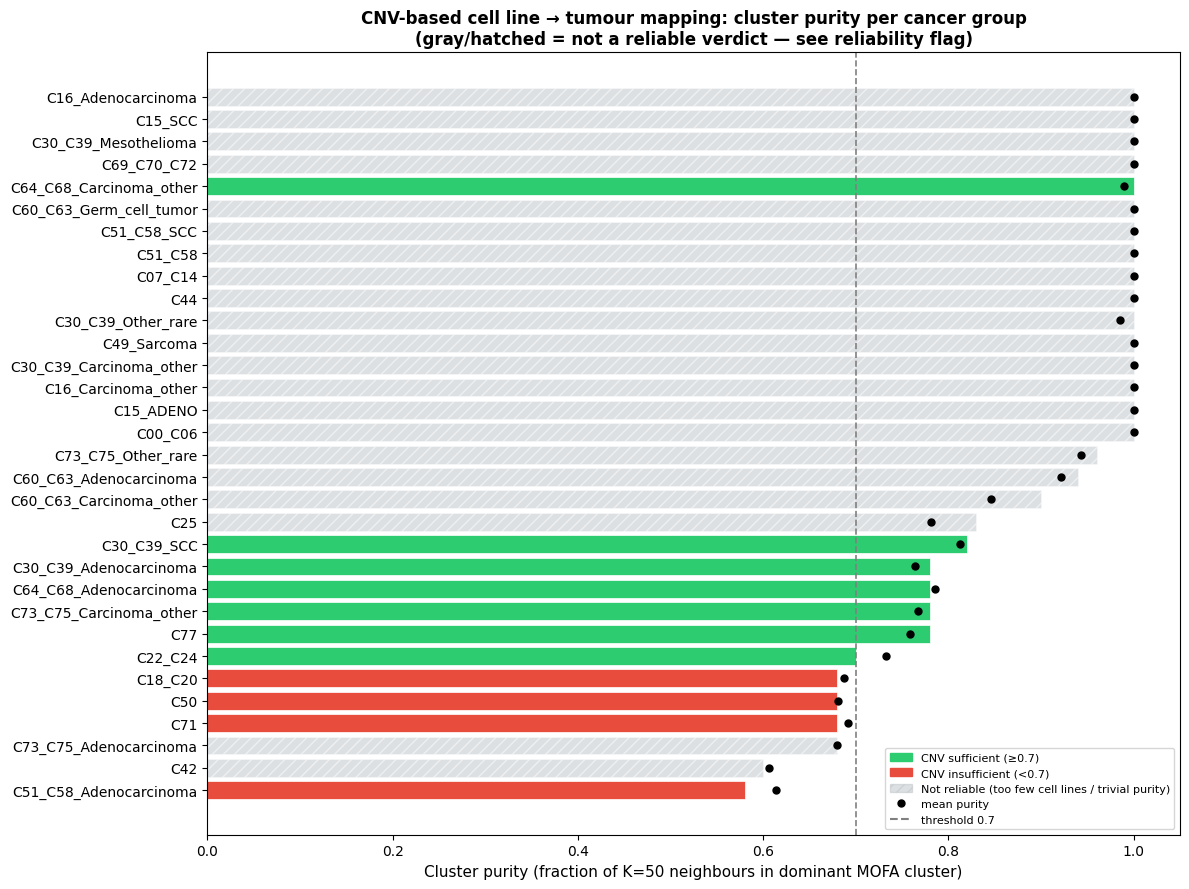

Saved: 01_purity_per_group_reliability.png


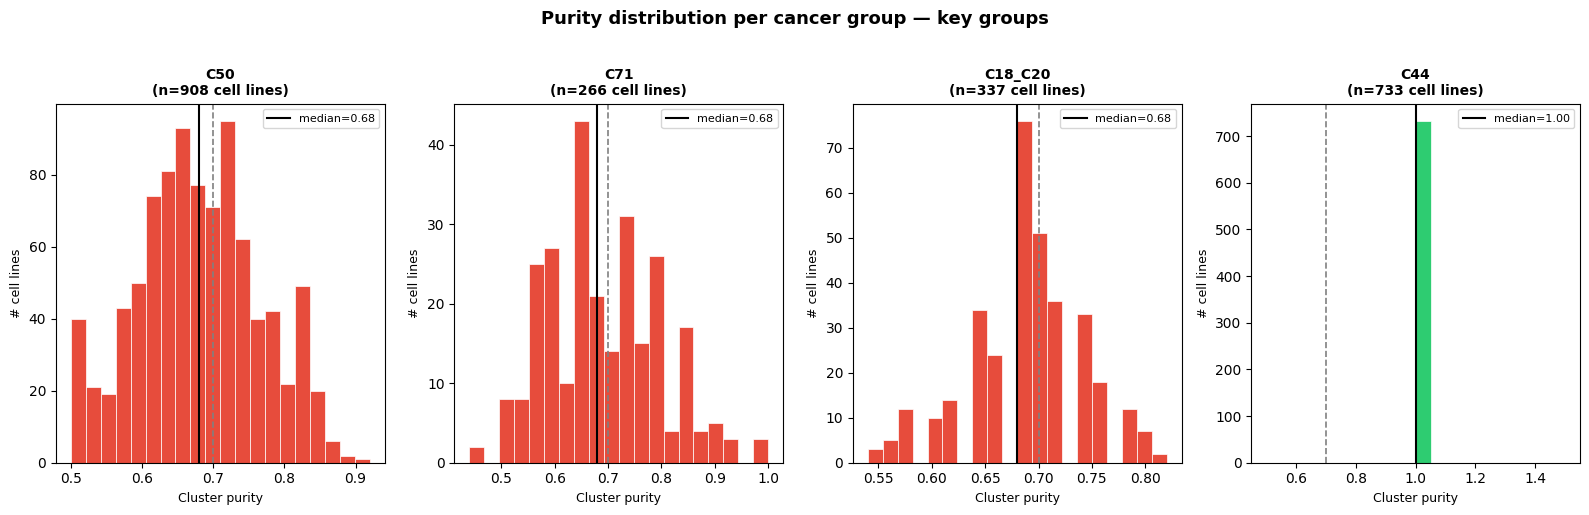

  → Saved: 02_purity_distribution_key_groups.png


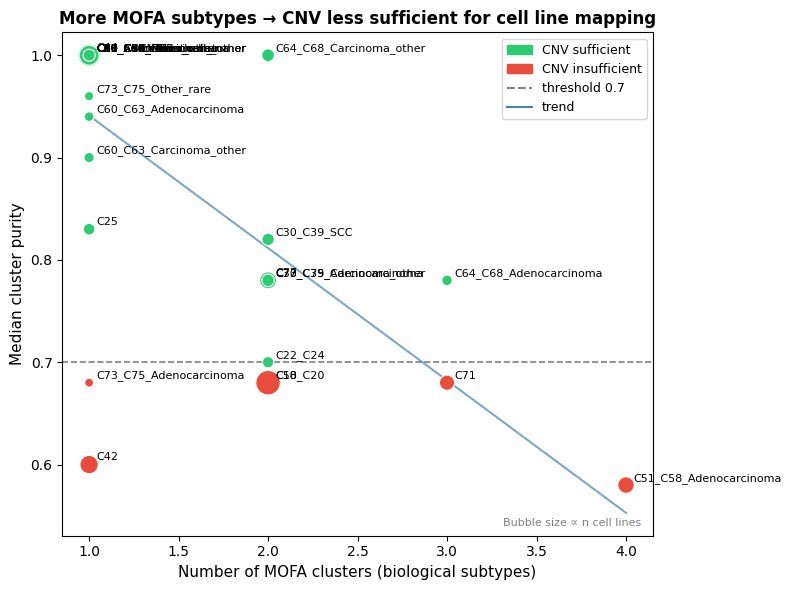

  → Saved: 03_nmofa_vs_purity.png

All figures saved to: /Users/bgadmin/Downloads/multiomics_preproc/inference/figures


In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

FIG_DIR = INFERENCE_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Color palette 
COLOR_SUFFICIENT     = "#2ecc71"   # green
COLOR_NOT_SUFFICIENT = "#e74c3c"   # red

#  Barplot purity per cancer group (reliability-aware) 
fig, ax = plt.subplots(figsize=(12, 9))

df_plot = summary_df.sort_values("median_purity", ascending=True).copy()

def bar_color(row):
    if row["reliability"] != "Reliable":
        return "#bdc3c7"  # gray — not a valid verdict
    return COLOR_SUFFICIENT if row["cnv_sufficient"] else COLOR_NOT_SUFFICIENT

colors = df_plot.apply(bar_color, axis=1).tolist()

bars = ax.barh(df_plot["icdot_root"], df_plot["median_purity"],
               color=colors, edgecolor="white", linewidth=0.5)

# Hatch unreliable bars for extra visual distinction
for bar, rel in zip(bars, df_plot["reliability"]):
    if rel != "Reliable":
        bar.set_hatch("///")
        bar.set_alpha(0.5)

ax.scatter(df_plot["mean_purity"], df_plot["icdot_root"],
           color="black", zorder=5, s=25, label="mean purity")

ax.axvline(0.7, color="gray", linestyle="--", linewidth=1.2, label="threshold (0.7)")

ax.set_xlabel("Cluster purity (fraction of K=50 neighbours in dominant MOFA cluster)",
              fontsize=11)
ax.set_title("CNV-based cell line → tumour mapping: cluster purity per cancer group\n"
             "(gray/hatched = not a reliable verdict — see reliability flag)",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, 1.05)

patch_s = mpatches.Patch(color=COLOR_SUFFICIENT,     label="CNV sufficient (≥0.7)")
patch_n = mpatches.Patch(color=COLOR_NOT_SUFFICIENT, label="CNV insufficient (<0.7)")
patch_u = mpatches.Patch(color="#bdc3c7", hatch="///", alpha=0.5,
                          label="Not reliable (too few cell lines / trivial purity)")
ax.legend(handles=[patch_s, patch_n, patch_u,
                   plt.Line2D([0], [0], color="black", marker="o", linestyle="",
                              markersize=5, label="mean purity"),
                   plt.Line2D([0], [0], color="gray", linestyle="--", label="threshold 0.7")],
          loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_purity_per_group_reliability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 01_purity_per_group_reliability.png")


#  Purity distribution for key groups 
key_groups = ["C50", "C71", "C64_C68", "C18_C20", "C44", "C16", "C40_C41_C48"]
key_groups = [g for g in key_groups if g in cl_purity_meta["icdot_root"].unique()]

fig, axes = plt.subplots(1, len(key_groups), figsize=(4 * len(key_groups), 5), sharey=False)

for ax, root in zip(axes, key_groups):
    data  = cl_purity_meta[cl_purity_meta["icdot_root"] == root]["cluster_purity"]
    color = (COLOR_SUFFICIENT
             if summary_df.loc[summary_df["icdot_root"] == root, "cnv_sufficient"].values[0]
             else COLOR_NOT_SUFFICIENT)

    ax.hist(data, bins=20, color=color, edgecolor="white", linewidth=0.5)
    ax.axvline(0.7, color="gray", linestyle="--", linewidth=1.2)
    ax.axvline(data.median(), color="black", linestyle="-", linewidth=1.5,
               label=f"median={data.median():.2f}")

    n_cl = len(data)
    ax.set_title(f"{root}\n(n={n_cl} cell lines)", fontsize=10, fontweight="bold")
    ax.set_xlabel("Cluster purity", fontsize=9)
    ax.set_ylabel("# cell lines", fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle("Purity distribution per cancer group — key groups",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_purity_distribution_key_groups.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → Saved: 02_purity_distribution_key_groups.png")


#  n_mofa_clusters vs median_purity 
fig, ax = plt.subplots(figsize=(8, 6))

df_sc = summary_df.dropna(subset=["n_mofa_clusters"]).copy()
df_sc["n_mofa_clusters"] = df_sc["n_mofa_clusters"].astype(int)

colors_sc = [COLOR_SUFFICIENT if v else COLOR_NOT_SUFFICIENT
             for v in df_sc["cnv_sufficient"]]

scatter = ax.scatter(df_sc["n_mofa_clusters"], df_sc["median_purity"],
                     c=colors_sc, s=df_sc["n_cell_lines"] * 0.3 + 40,
                     edgecolors="white", linewidths=0.8, zorder=3)

# Label each point
for _, row in df_sc.iterrows():
    ax.annotate(row["icdot_root"],
                xy=(row["n_mofa_clusters"], row["median_purity"]),
                xytext=(5, 3), textcoords="offset points", fontsize=8)

ax.axhline(0.7, color="gray", linestyle="--", linewidth=1.2, label="threshold (0.7)")

# Trend line
z = np.polyfit(df_sc["n_mofa_clusters"], df_sc["median_purity"], 1)
p = np.poly1d(z)
x_line = np.linspace(df_sc["n_mofa_clusters"].min(), df_sc["n_mofa_clusters"].max(), 100)
ax.plot(x_line, p(x_line), color="steelblue", linestyle="-", linewidth=1.5,
        alpha=0.7, label="trend")

ax.set_xlabel("Number of MOFA clusters (biological subtypes)", fontsize=11)
ax.set_ylabel("Median cluster purity", fontsize=11)
ax.set_title("More MOFA subtypes → CNV less sufficient for cell line mapping",
             fontsize=12, fontweight="bold")

patch_s = mpatches.Patch(color=COLOR_SUFFICIENT,     label="CNV sufficient")
patch_n = mpatches.Patch(color=COLOR_NOT_SUFFICIENT, label="CNV insufficient")
ax.legend(handles=[patch_s, patch_n,
                   plt.Line2D([0], [0], color="gray",     linestyle="--", label="threshold 0.7"),
                   plt.Line2D([0], [0], color="steelblue", linestyle="-",  label="trend")],
          fontsize=9)

# Note: bubble size = n cell lines
ax.text(0.98, 0.02, "Bubble size ∝ n cell lines",
        transform=ax.transAxes, ha="right", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig(FIG_DIR / "03_nmofa_vs_purity.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → Saved: 03_nmofa_vs_purity.png")

print(f"\nAll figures saved to: {FIG_DIR}")

### Investigation CNV vs Multi-omics VS Inference cell line mapping

In [36]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [37]:
INFERENCE_DIR = Path("/Users/bgadmin/Downloads/multiomics_preproc/inference")
OUT_FIG       = INFERENCE_DIR / "figures"
OUT_FIG.mkdir(parents=True, exist_ok=True)

In [38]:
#  Load inference summary 
summary_df = pd.read_csv(INFERENCE_DIR / "inference_summary_per_group.tsv", sep="\t")
print(f"Inference summary: {summary_df.shape}")
print(summary_df.columns.tolist())

Inference summary: (32, 14)
['icdot_root', 'n_cell_lines', 'n_mofa_clusters', 'mean_purity', 'median_purity', 'n_high_purity', 'n_low_purity', 'pct_high_purity', 'pct_low_purity', 'cnv_sufficient', 'trivial_purity', 'too_few_cell_lines', 'reliability', 'cnv_sufficient_reliable']


In [39]:
cnv_to_mofa = {
    "C00_C06"                  : "Oral_cavity (C00-C06)",
    "C07_C14"                  : "Pharynx (C07-C14)",
    "C15_SCC"                  : "Esophagus_SCC (C15)",
    "C15_ADENO"                : "Esophagus_ADENO (C15)",
    "C16_Adenocarcinoma"       : "C16_Adenocarcinoma",
    "C16_Carcinoma_other"      : "C16_Carcinoma_other",
    "C18_C20"                  : "Colorectal (C18-C20)",
    "C22_C24"                  : "Liver/Biliary (C22-C24)",
    "C25"                      : "C25",
    "C30_C39_Adenocarcinoma"   : "Lung_Adenocarcinoma",
    "C30_C39_Carcinoma_other"  : "Lung_Carcinoma_other",
    "C30_C39_Mesothelioma"     : "Lung_Mesothelioma",
    "C30_C39_Other_rare"       : "Lung_Other_rare",
    "C30_C39_SCC"              : "Lung_SCC",
    "C40_C41_C48_Sarcoma"      : "Bone/SoftTissue_Sarcoma",
    "C42"                      : "Blood/Lymph (C42)",
    "C44"                      : "Skin (C44)",
    "C49_Melanoma"             : "SoftTissue_Melanoma",
    "C49_Sarcoma"              : "SoftTissue_Sarcoma",
    "C50"                      : "Breast (C50)",
    "C51_C58"                  : "Gynecologic (C51-C58)",
    "C51_C58_Adenocarcinoma"   : "Gynecologic_Adenocarcinoma",
    "C51_C58_SCC"              : "Gynecologic_SCC",
    "C60_C63_Adenocarcinoma"   : "Male genital_Adenocarcinoma",
    "C60_C63_Carcinoma_other"  : "Male genital_Carcinoma_other",
    "C60_C63_Germ_cell_tumor"  : "Male genital_Germ_cell_tumor",
    "C64_C68_Adenocarcinoma"   : "Urinary_Adenocarcinoma",
    "C64_C68_Carcinoma_other"  : "Urinary_Carcinoma_other",
    "C69_C70_C72"              : "Eye/CNS (C69-C72)",
    "C71"                      : "Brain (C71)",
    "C73_C75_Adenocarcinoma"   : "Thyroid/Endocrine_Adenocarcinoma",
    "C73_C75_Carcinoma_other"  : "Thyroid/Endocrine_Carcinoma_other",
    "C73_C75_Other_rare"       : "Thyroid/Endocrine_Other_rare",
    "C77"                      : "Lymph nodes (C77)",
}

# 2) Load the V4 comparison results (CNV-only vs MOFA), produced by
#    the other notebook. This file already contains the final
#    "interpretation" (CNV sufficient / Multi-omic adds value / ...)
#    for each V4 group.
final_table_v4 = pd.read_csv(
    Path("/Users/bgadmin/Downloads/multiomics_preproc/comparison_axe1_vs_axe2")
    / "comparison_final_unified.tsv",
    sep="\t"
)

# 3) Reverse cnv_to_mofa (mofa cancer_group → cnv root) so we can key
#    INVESTIGATION_MAP on the SAME root names as icdot_root_mapped
#    in this inference notebook.
mofa_to_cnv_root = {v: k for k, v in cnv_to_mofa.items()}

INVESTIGATION_MAP = {}
for _, row in final_table_v4.iterrows():
    cnv_root = mofa_to_cnv_root.get(row["cancer_group"])
    if cnv_root is not None:
        INVESTIGATION_MAP[cnv_root] = row["interpretation"]

print(f"\nINVESTIGATION_MAP auto-built with {len(INVESTIGATION_MAP)} V4 roots:")
for k, v in INVESTIGATION_MAP.items():
    print(f"  {k:35s} → {v}")


INVESTIGATION_MAP auto-built with 34 V4 roots:
  C42                                 → Too small — unreliable
  C71                                 → Multi-omic adds value
  C60_C63_Germ_cell_tumor             → Too small — unreliable
  C30_C39_Other_rare                  → Too small — unreliable
  C64_C68_Adenocarcinoma              → CNV sufficient
  C51_C58_Adenocarcinoma              → CNV sufficient
  C44                                 → Too small — unreliable
  C00_C06                             → CNV sufficient
  C49_Sarcoma                         → Too small — unreliable
  C22_C24                             → CNV sufficient
  C16_Adenocarcinoma                  → Neutral — no clear winner
  C18_C20                             → CNV sufficient
  C69_C70_C72                         → Too small — unreliable
  C73_C75_Other_rare                  → Neutral — conflicting signals
  C51_C58_SCC                         → Neutral — no clear winner
  C77                              

In [40]:
inference_roots = set(summary_df["icdot_root"].unique())
mapped_roots     = set(INVESTIGATION_MAP.keys())
unmatched = inference_roots - mapped_roots
if unmatched:
    print(f"\n Roots with no investigation classification "
          f"(likely 'Too small' groups, excluded from final_table_v4): {unmatched}")


In [41]:
# Color palette (V4-agnostic, matches the comparison notebook)
INTERP_COLORS = {
    "Multi-omic adds value":                         "#2ecc71",
    "Multi-omic adds value — global structure only": "#27ae60",
    "CNV sufficient":                                "#e74c3c",
    "Neutral — conflicting signals":                 "#f39c12",
    "Neutral — no clear winner":                     "#95a5a6",
    "Too small — unreliable":                        "#bdc3c7",
}

df_cross = summary_df.copy()
df_cross["investigation_classification"] = df_cross["icdot_root"].map(INVESTIGATION_MAP)
df_cross["investigation_color"] = df_cross["investigation_classification"].map(INTERP_COLORS)

# Groups with no match at all → treat as "Not analysed", not a crash
df_cross["investigation_classification"] = df_cross["investigation_classification"].fillna(
    "Not analysed in investigation"
)

# Inference binary classification
df_cross["inference_cnv_sufficient"] = df_cross["median_purity"] >= 0.7

print(df_cross[["icdot_root", "investigation_classification",
                "median_purity", "inference_cnv_sufficient"]].to_string(index=False))

             icdot_root                  investigation_classification  median_purity  inference_cnv_sufficient
                C00_C06                                CNV sufficient           1.00                      True
   C30_C39_Mesothelioma                        Too small — unreliable           1.00                      True
            C69_C70_C72                        Too small — unreliable           1.00                      True
C64_C68_Carcinoma_other                 Neutral — conflicting signals           1.00                      True
C60_C63_Germ_cell_tumor                        Too small — unreliable           1.00                      True
            C51_C58_SCC                     Neutral — no clear winner           1.00                      True
                C51_C58                        Too small — unreliable           1.00                      True
                C07_C14                        Too small — unreliable           1.00                      True
 

In [42]:
#  Concordance classification 
def concordance_label(row):
    inv = row["investigation_classification"]
    inf = row["inference_cnv_sufficient"]

    # Not analysed / too small — no investigation ground truth to compare against
    if inv in ("Too small — unreliable", "Not analysed in investigation"):
        return "Not analysed in investigation"

    inv_cnv  = "CNV sufficient" in inv
    inv_mofa = "Multi-omic" in inv

    if inv_cnv and inf:
        return "Agreement — CNV sufficient"
    elif inv_mofa and not inf:
        return "Agreement — Multi-omic needed"
    elif inv_cnv and not inf:
        return "Divergence — CNV sufficient (investigation) but poor mapping (inference)"
    elif inv_mofa and inf:
        return "Divergence — Multi-omic (investigation) but good mapping (inference)"
    else:
        return "Neutral — ambiguous"

df_cross["concordance"] = df_cross.apply(concordance_label, axis=1)

print("\nConcordance summary:")
print(df_cross["concordance"].value_counts())
print()
print(df_cross[["icdot_root", "investigation_classification",
                "median_purity", "concordance"]].to_string(index=False))


Concordance summary:
concordance
Not analysed in investigation                                               13
Neutral — ambiguous                                                          8
Agreement — CNV sufficient                                                   5
Divergence — CNV sufficient (investigation) but poor mapping (inference)     4
Divergence — Multi-omic (investigation) but good mapping (inference)         1
Agreement — Multi-omic needed                                                1
Name: count, dtype: int64

             icdot_root                  investigation_classification  median_purity                                                              concordance
                C00_C06                                CNV sufficient           1.00                                               Agreement — CNV sufficient
   C30_C39_Mesothelioma                        Too small — unreliable           1.00                                            Not analysed in inves

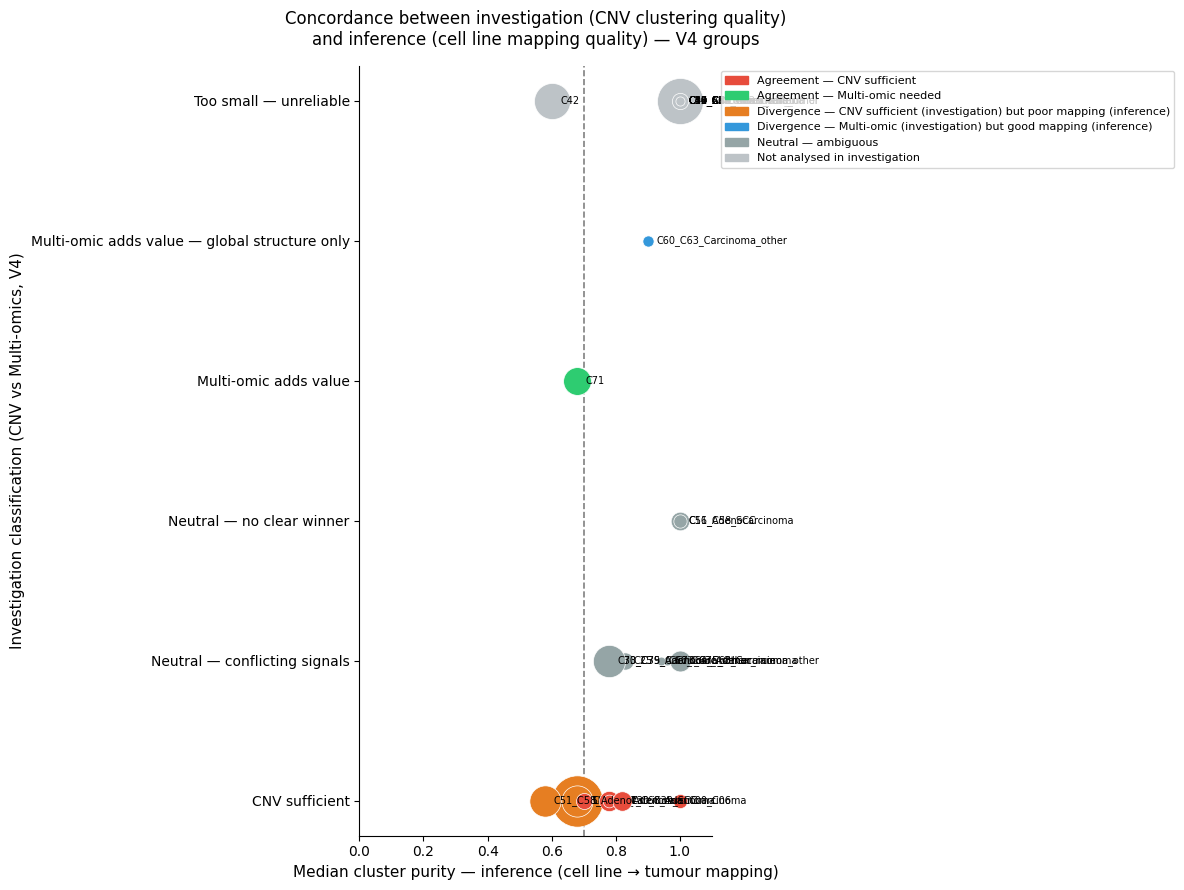

In [43]:
# Scatter: investigation vs inference 
CONCORD_COLORS = {
    "Agreement — CNV sufficient":                                                 "#e74c3c",
    "Agreement — Multi-omic needed":                                              "#2ecc71",
    "Divergence — CNV sufficient (investigation) but poor mapping (inference)":   "#e67e22",
    "Divergence — Multi-omic (investigation) but good mapping (inference)":       "#3498db",
    "Neutral — ambiguous":                                                        "#95a5a6",
    "Not analysed in investigation":                                              "#bdc3c7",
}

INV_ORDER = [
    "CNV sufficient",
    "Neutral — conflicting signals",
    "Neutral — no clear winner",
    "Multi-omic adds value",
    "Multi-omic adds value — global structure only",
    "Too small — unreliable",
    "Not analysed in investigation",
]

df_plot = df_cross.copy()
df_plot["inv_order"] = df_plot["investigation_classification"].map(
    {v: i for i, v in enumerate(INV_ORDER)}
)
# Anything not in INV_ORDER (shouldn't happen, but just in case) goes last
df_plot["inv_order"] = df_plot["inv_order"].fillna(len(INV_ORDER))
df_plot = df_plot.sort_values("inv_order")

fig, ax = plt.subplots(figsize=(12, 9))

for _, row in df_plot.iterrows():
    color = CONCORD_COLORS.get(row["concordance"], "#cccccc")
    ax.scatter(
        row["median_purity"],
        row["investigation_classification"],
        color=color,
        s=max(row["n_cell_lines"] * 1.5, 40),
        edgecolors="white",
        linewidths=0.5,
        zorder=3,
    )
    ax.annotate(
        row["icdot_root"],
        xy=(row["median_purity"], row["investigation_classification"]),
        xytext=(6, 0), textcoords="offset points",
        fontsize=7, va="center",
    )

ax.axvline(0.7, color="gray", linestyle="--", linewidth=1.2, label="purity threshold (0.7)")

patches = [mpatches.Patch(color=v, label=k) for k, v in CONCORD_COLORS.items()]
ax.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

ax.set_xlabel("Median cluster purity — inference (cell line → tumour mapping)", fontsize=11)
ax.set_ylabel("Investigation classification (CNV vs Multi-omics, V4)", fontsize=11)
ax.set_title(
    "Concordance between investigation (CNV clustering quality)\n"
    "and inference (cell line mapping quality) — V4 groups",
    fontsize=12, pad=15,
)
ax.set_xlim(0, 1.1)
sns.despine()
plt.tight_layout()
plt.savefig(OUT_FIG / "cross_investigation_vs_inference.png", dpi=150, bbox_inches="tight")
plt.show()

In [44]:
#  Divergence analysis — explain each divergent group 
divergent = df_cross[df_cross["concordance"].str.startswith("Divergence")].copy()

for _, row in divergent.iterrows():
    print(f"\n{'─'*70}")
    print(f"Group         : {row['icdot_root']}")
    print(f"Investigation : {row['investigation_classification']}")
    print(f"Inference     : median purity = {row['median_purity']:.3f} "
          f"({'sufficient' if row['inference_cnv_sufficient'] else 'insufficient'})")
    print(f"n cell lines  : {row['n_cell_lines']}")
    print(f"n MOFA clusters: {row['n_mofa_clusters']}")
    print(f"% high purity : {row['pct_high_purity']}%")
    print(f"% low purity  : {row['pct_low_purity']}%")


──────────────────────────────────────────────────────────────────────
Group         : C60_C63_Carcinoma_other
Investigation : Multi-omic adds value — global structure only
Inference     : median purity = 0.900 (sufficient)
n cell lines  : 43
n MOFA clusters: 1
% high purity : 69.8%
% low purity  : 0.0%

──────────────────────────────────────────────────────────────────────
Group         : C18_C20
Investigation : CNV sufficient
Inference     : median purity = 0.680 (insufficient)
n cell lines  : 337
n MOFA clusters: 2
% high purity : 0.6%
% low purity  : 0.0%

──────────────────────────────────────────────────────────────────────
Group         : C50
Investigation : CNV sufficient
Inference     : median purity = 0.680 (insufficient)
n cell lines  : 908
n MOFA clusters: 2
% high purity : 8.6%
% low purity  : 0.0%

──────────────────────────────────────────────────────────────────────
Group         : C73_C75_Adenocarcinoma
Investigation : CNV sufficient
Inference     : median purity = 0.

In [45]:
#Summary table — final cross-analysis 
cols_display = [
    "icdot_root",
    "investigation_classification",
    "n_cell_lines",
    "n_mofa_clusters",
    "median_purity",
    "pct_high_purity",
    "pct_low_purity",
    "concordance",
]

df_final = df_cross[cols_display].copy()
df_final = df_final.sort_values(
    ["concordance", "median_purity"],
    ascending=[True, False]
)

print(df_final.to_string(index=False))

df_final.to_csv(
    INFERENCE_DIR / "cross_investigation_inference.tsv",
    sep="\t", index=False
)
print("\nSaved: cross_investigation_inference.tsv")

             icdot_root                  investigation_classification  n_cell_lines  n_mofa_clusters  median_purity  pct_high_purity  pct_low_purity                                                              concordance
                C00_C06                                CNV sufficient            69                1           1.00            100.0             0.0                                               Agreement — CNV sufficient
            C30_C39_SCC                                CNV sufficient           131                2           0.82             56.5             0.0                                               Agreement — CNV sufficient
 C64_C68_Adenocarcinoma                                CNV sufficient            56                3           0.78             21.4             0.0                                               Agreement — CNV sufficient
                    C77                                CNV sufficient           140                2           0

### ANALYSIS OF MISMAPPED LINES

In [46]:
knn_annotated = pd.read_parquet(INFERENCE_DIR / "celllines_knn_annotated.parquet")
cl_purity     = pd.read_parquet(INFERENCE_DIR / "celllines_cluster_purity.parquet")

print(f"knn_annotated : {knn_annotated.shape}")
print(f"cl_purity     : {cl_purity.shape}")
print(knn_annotated.columns.tolist())

knn_annotated : (264150, 8)
cl_purity     : (5283, 9)
['cl_biosample_id', 'cl_analysis_id', 'icdot_root', 'rank', 'tumour_biosample_id', 'distance', 'tumour_cancer_group', 'tumour_cluster']


In [47]:
# Define groups to investigate 
# Groups with concordance issues or poor purity
FOCUS_GROUPS = {
    # Divergent — CNV sufficient in investigation but poor mapping
    "C50":              "Divergence — Breast (CNV sufficient but poor mapping)",
    "C18_C20":          "Divergence — Colorectal (CNV sufficient but poor mapping)",
    # Agreement — Multi-omic needed, poor mapping confirms it
    "C71":              "Agreement — Brain (multi-omic needed)",
    "C15_C17_C21_C26":  "Agreement — Esophagus/Intestine (multi-omic needed)",
    "C64_C68":          "Agreement — Urinary (multi-omic needed)",
    "C73_C75":          "Agreement — Thyroid (borderline)",
    # Too small but poor mapping
    "C44":              "Too small — Skin (heterogeneous)",
    "C42":              "Too small — Blood (heterogeneous)",
}

In [48]:
#  For each focus group: where do cell lines end up? ─────

mismapping_records = []

for root, label in FOCUS_GROUPS.items():
    # Get cell lines for this root
    cl_root = cl_purity[cl_purity["icdot_root"] == root].copy()
    if cl_root.empty:
        print(f"\n  {root} — no data")
        continue

    # Split into well-mapped and poorly-mapped
    well_mapped   = cl_root[cl_root["cluster_purity"] >= 0.7]
    poorly_mapped = cl_root[cl_root["cluster_purity"] <  0.7]

    print(f"GROUP: {root}  [{label}]")
    print(f"  Total cell lines    : {len(cl_root)}")
    print(f"  Well mapped  (≥0.7) : {len(well_mapped)}  ({len(well_mapped)/len(cl_root)*100:.1f}%)")
    print(f"  Poorly mapped (<0.7): {len(poorly_mapped)}  ({len(poorly_mapped)/len(cl_root)*100:.1f}%)")

    if len(poorly_mapped) == 0:
        print("  → All well mapped, skipping.")
        continue

    # For poorly mapped: what dominant cluster did they land in?
    print(f"\n  Dominant cluster distribution (poorly mapped cell lines):")
    cluster_dist = poorly_mapped["dominant_cluster"].value_counts()
    for cl_id, count in cluster_dist.items():
        pct = count / len(poorly_mapped) * 100
        print(f"    Cluster {cl_id} : {count} cell lines ({pct:.1f}%)")

    # Mean purity per dominant cluster
    print(f"\n  Mean purity per dominant cluster (all cell lines):")
    purity_per_cluster = (
        cl_root.groupby("dominant_cluster")["cluster_purity"]
        .agg(["mean", "count"])
        .round(3)
    )
    print(purity_per_cluster.to_string())

    for _, row in poorly_mapped.iterrows():
        mismapping_records.append({
            "icdot_root":       root,
            "label":            label,
            "cl_biosample_id":  row["cl_biosample_id"],
            "dominant_cluster": row["dominant_cluster"],
            "cluster_purity":   row["cluster_purity"],
            "mean_distance":    row["mean_distance"],
        })

df_mismapped = pd.DataFrame(mismapping_records)
print(f"\n\nTotal poorly mapped cell lines across focus groups: {len(df_mismapped)}")

GROUP: C50  [Divergence — Breast (CNV sufficient but poor mapping)]
  Total cell lines    : 908
  Well mapped  (≥0.7) : 410  (45.2%)
  Poorly mapped (<0.7): 498  (54.8%)

  Dominant cluster distribution (poorly mapped cell lines):
    Cluster 0 : 492 cell lines (98.8%)
    Cluster 1 : 6 cell lines (1.2%)

  Mean purity per dominant cluster (all cell lines):
                   mean  count
dominant_cluster              
0                 0.682    902
1                 0.527      6
GROUP: C18_C20  [Divergence — Colorectal (CNV sufficient but poor mapping)]
  Total cell lines    : 337
  Well mapped  (≥0.7) : 159  (47.2%)
  Poorly mapped (<0.7): 178  (52.8%)

  Dominant cluster distribution (poorly mapped cell lines):
    Cluster 0 : 178 cell lines (100.0%)

  Mean purity per dominant cluster (all cell lines):
                   mean  count
dominant_cluster              
0                 0.687    337
GROUP: C71  [Agreement — Brain (multi-omic needed)]
  Total cell lines    : 266
  Well map

In [49]:
#  Neighbour cluster distribution for poorly mapped 

for root in FOCUS_GROUPS:
    poorly_ids = df_mismapped[df_mismapped["icdot_root"] == root]["cl_biosample_id"].tolist()
    if not poorly_ids:
        continue

    # Get all neighbours for these cell lines
    neighbours = knn_annotated[
        (knn_annotated["icdot_root"] == root) &
        (knn_annotated["cl_biosample_id"].isin(poorly_ids))
    ].copy()

    if neighbours.empty:
        continue

    neighbours_annotated = neighbours.dropna(subset=["tumour_cluster"])
    total_neighbours = len(neighbours_annotated)

    if total_neighbours == 0:
        continue

    cluster_counts = (
        neighbours_annotated["tumour_cluster"]
        .value_counts()
        .reset_index()
    )
    cluster_counts.columns = ["cluster", "n_neighbours"]
    cluster_counts["pct"] = (cluster_counts["n_neighbours"] / total_neighbours * 100).round(1)

    print(f"GROUP: {root}  ({len(poorly_ids)} poorly mapped cell lines)")
    print(f"Neighbour distribution across tumour clusters:")
    print(cluster_counts.to_string(index=False))

    # Entropy — measure of dispersion
    probs = cluster_counts["pct"].values / 100
    probs = probs[probs > 0]
    entropy = -np.sum(probs * np.log2(probs))
    max_entropy = np.log2(len(cluster_counts))
    normalized_entropy = entropy / max_entropy if max_entropy > 0 else 0

    print(f"Normalized entropy : {normalized_entropy:.3f}  "
          f"(0=concentrated in 1 cluster, 1=dispersed equally)")

GROUP: C50  (498 poorly mapped cell lines)
Neighbour distribution across tumour clusters:
 cluster  n_neighbours  pct
       0         15428 62.0
       1          9472 38.0
Normalized entropy : 0.958  (0=concentrated in 1 cluster, 1=dispersed equally)
GROUP: C18_C20  (178 poorly mapped cell lines)
Neighbour distribution across tumour clusters:
 cluster  n_neighbours  pct
       0          5767 64.8
       1          3133 35.2
Normalized entropy : 0.936  (0=concentrated in 1 cluster, 1=dispersed equally)
GROUP: C71  (144 poorly mapped cell lines)
Neighbour distribution across tumour clusters:
 cluster  n_neighbours  pct
       0          4353 60.5
       2          2371 32.9
       1           476  6.6
Normalized entropy : 0.773  (0=concentrated in 1 cluster, 1=dispersed equally)
GROUP: C42  (428 poorly mapped cell lines)
Neighbour distribution across tumour clusters:
 cluster  n_neighbours  pct
       0         12795 59.8
      -1          8605 40.2
Normalized entropy : 0.972  (0=conc

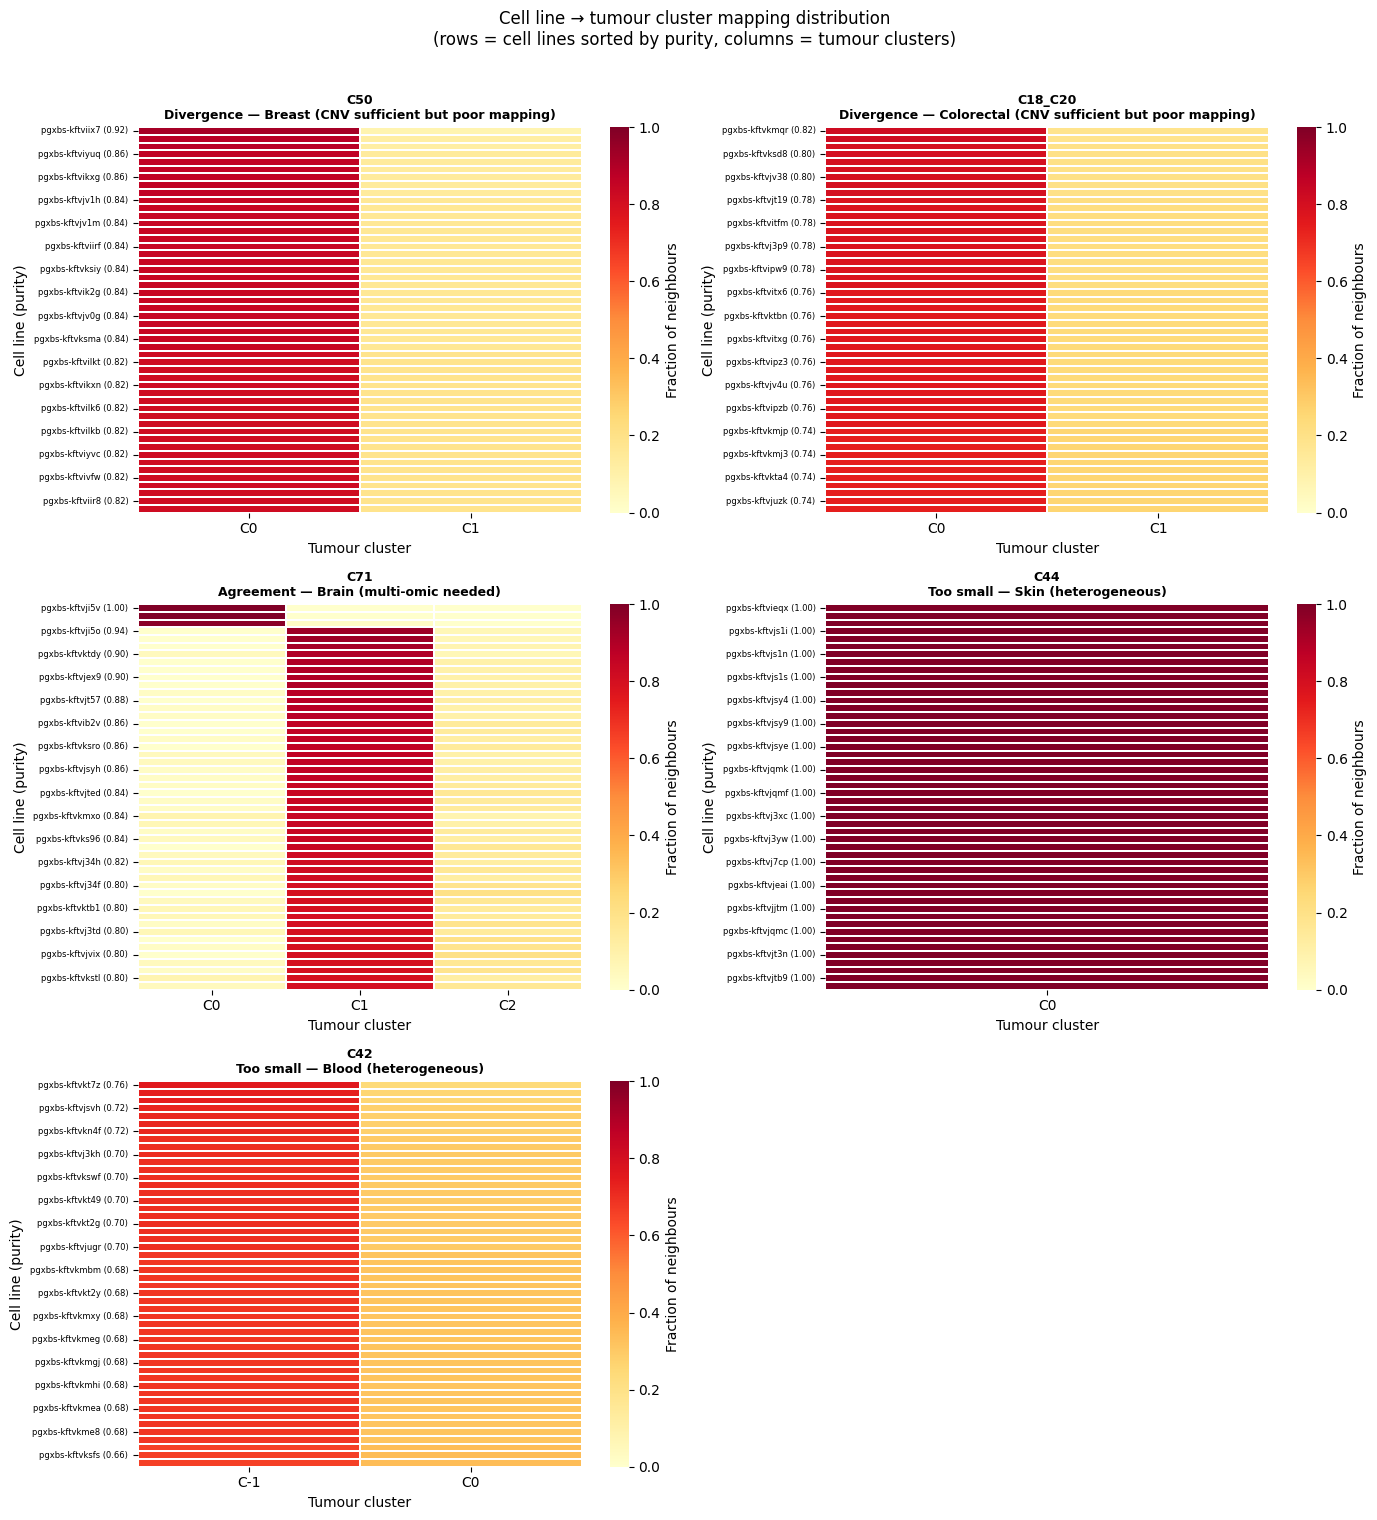

Saved: mismapping_heatmap.png


In [50]:
# Fig — Heatmap: cell line → tumour cluster distribution
fig_groups = [r for r in FOCUS_GROUPS if r in knn_annotated["icdot_root"].unique()]

n_groups = len(fig_groups)
ncols = 2
nrows = (n_groups + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 5))
axes = axes.flatten()

for idx, root in enumerate(fig_groups):
    ax = axes[idx]

    cl_root = cl_purity[cl_purity["icdot_root"] == root].copy()
    if cl_root.empty:
        ax.set_visible(False)
        continue

    # Sort cell lines by purity descending
    cl_root = cl_root.sort_values("cluster_purity", ascending=False)
    purity_vals = cl_root.set_index("cl_biosample_id")["cluster_purity"]

    # Build pivot — only for cell lines that have annotated neighbours
    pivot_data = {}

    for cl_id in cl_root["cl_biosample_id"].tolist()[:50]:
        nbrs = knn_annotated[
            (knn_annotated["icdot_root"] == root) &
            (knn_annotated["cl_biosample_id"] == cl_id)
        ].dropna(subset=["tumour_cluster"])

        if nbrs.empty:
            continue

        total = len(nbrs)
        dist  = (nbrs["tumour_cluster"].value_counts() / total).to_dict()

        p     = purity_vals.get(cl_id, np.nan)
        label = (f"{str(cl_id)[:15]}… ({p:.2f})"
                 if len(str(cl_id)) > 15
                 else f"{cl_id} ({p:.2f})")
        pivot_data[label] = dist

    if not pivot_data:
        ax.set_visible(False)
        continue

    df_pivot = pd.DataFrame(pivot_data).T.fillna(0)
    # Rename columns: cluster ids → C0, C1, ...
    df_pivot.columns = [f"C{int(c)}" for c in sorted(df_pivot.columns)]

    sns.heatmap(
        df_pivot,
        cmap="YlOrRd",
        vmin=0, vmax=1,
        ax=ax,
        cbar_kws={"label": "Fraction of neighbours"},
        linewidths=0.3,
        linecolor="white",
    )

    # y tick labels are already the index of df_pivot — no need to set manually
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)
    ax.set_title(
        f"{root}\n{FOCUS_GROUPS[root]}",
        fontsize=9, fontweight="bold"
    )
    ax.set_xlabel("Tumour cluster")
    ax.set_ylabel("Cell line (purity)")

# Hide unused axes
for idx in range(len(fig_groups), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(
    "Cell line → tumour cluster mapping distribution\n"
    "(rows = cell lines sorted by purity, columns = tumour clusters)",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(OUT_FIG / "mismapping_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: mismapping_heatmap.png")

In [51]:
#  systematic vs random mismapping? ───────
"""
Systematic mismapping = all poorly mapped cell lines land in the SAME
wrong cluster → suggests a biological bias (cell lines represent only
one subtype).

Random mismapping = poorly mapped cell lines are dispersed across all
clusters → suggests the cell line CNV profile doesn't match any tumour
subtype well (biological distance / in vitro drift).
"""
for root in FOCUS_GROUPS:
    poorly_ids = df_mismapped[df_mismapped["icdot_root"] == root]["cl_biosample_id"].tolist()
    if not poorly_ids:
        continue

    cl_root_poorly = cl_purity[
        (cl_purity["icdot_root"] == root) &
        (cl_purity["cl_biosample_id"].isin(poorly_ids))
    ]

    if cl_root_poorly.empty:
        continue

    dominant_counts = cl_root_poorly["dominant_cluster"].value_counts()
    top_cluster_pct = dominant_counts.iloc[0] / len(cl_root_poorly) * 100
    n_clusters_hit  = len(dominant_counts)

    if top_cluster_pct >= 70:
        pattern = "SYSTEMATIC — biased toward one cluster"
    elif n_clusters_hit == 1:
        pattern = "SYSTEMATIC — all in same cluster"
    else:
        pattern = "DISPERSED — spread across multiple clusters"

    print(f"  {root:20s} : {pattern}  "
          f"(top cluster = {top_cluster_pct:.0f}% of poorly mapped, "
          f"{n_clusters_hit} clusters hit)")

  C50                  : SYSTEMATIC — biased toward one cluster  (top cluster = 99% of poorly mapped, 2 clusters hit)
  C18_C20              : SYSTEMATIC — biased toward one cluster  (top cluster = 100% of poorly mapped, 1 clusters hit)
  C71                  : SYSTEMATIC — biased toward one cluster  (top cluster = 95% of poorly mapped, 3 clusters hit)
  C42                  : SYSTEMATIC — biased toward one cluster  (top cluster = 94% of poorly mapped, 2 clusters hit)
